## Chebyshev 2: Differentiation

In [7]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

# SEABORN & MATPLOTLIBN CONFIGURATION
# seaborn styles (choose by changing index at end)
context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4] 

# extra customizations
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
# uncomment this to get list of all rc-params: 
#print(plt.rcParams.keys())
rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.8.16 (default, Jun 12 2023, 18:09:05) 
[GCC 11.2.0]
Seaborn version 0.12.2


In [8]:
sys.path.append('../Final')
import Chebyshev

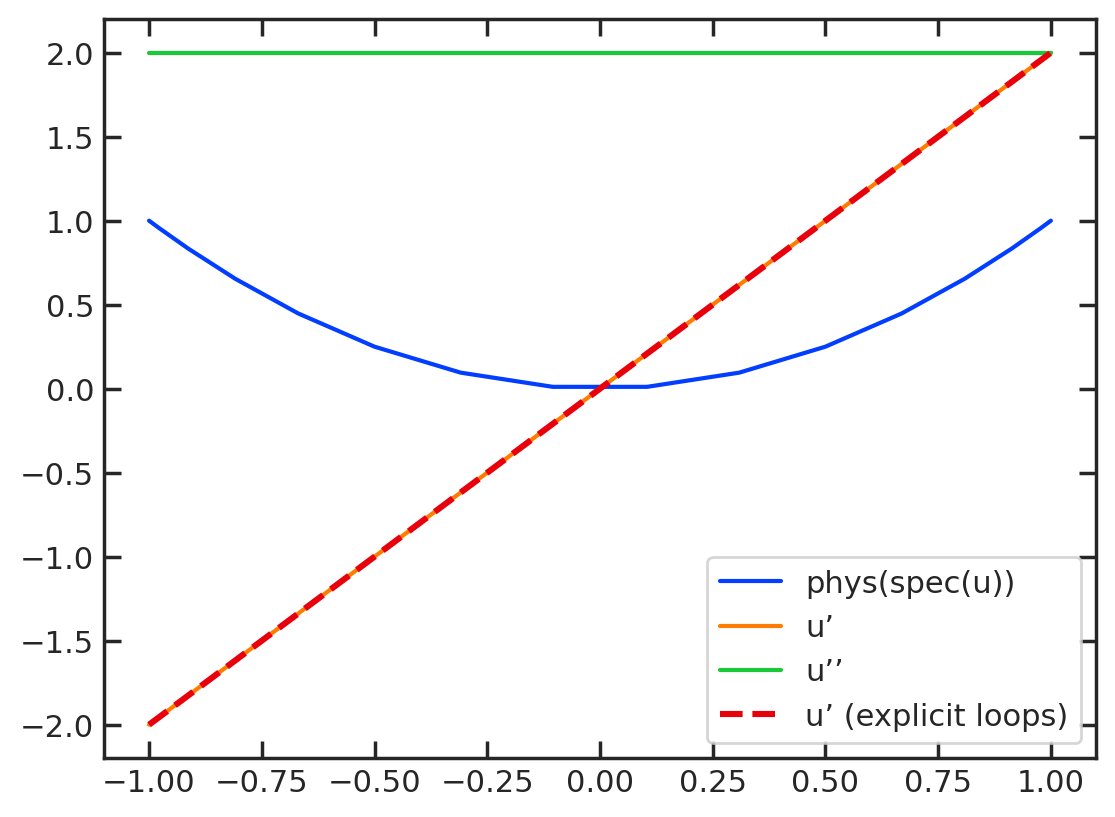

In [10]:
N=16
x,ToSpec,ToPhys,D1,D2 = Chebyshev.ChebyshevHelpers(N)

u = x**2   #<====   u = x^2   (Fourier bad: slow 1/k convergence + Gibbs)

plt.plot(x, ToPhys @ (ToSpec @ u), label="phys(spec(u))")
plt.plot(x, D1 @ u, label="u’")
plt.plot(x, D2 @ u, label="u’’")

# # or ...
du = np.zeros(N)
for i in range(N):
    for j in range(N):
        du[i] += D1[i,j]*u[j]
plt.plot(x, du, '--', lw=2.2, label="u’ (explicit loops)")

plt.legend();

In [11]:
uspec = ToSpec @ u
print(f"spectral coefficients of u:       : {np.round(uspec,decimals=4)}")

du_spec = ToSpec @ ( D1 @ u)
print(f"spectral coefficients of dudx     : {np.round(du_spec,decimals=4)}")

ddu_spec = ToSpec @ ( D2 @ u)
print(f"spectral coefficients of d^2udx^2 : {np.round(ddu_spec,decimals=4)}")


spectral coefficients of u:       : [ 0.5 -0.   0.5  0.   0.   0.   0.   0.   0.   0.   0.  -0.  -0.  -0.
  0.   0. ]
spectral coefficients of dudx     : [-0.  2. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0.  0.  0.]
spectral coefficients of d^2udx^2 : [ 2. -0.  0. -0.  0. -0.  0. -0.  0. -0. -0.  0. -0.  0. -0.  0.]
